# CSCI 111 Final Project

Albel, Rasheed

Eltagonde, Val Allen

Layug, Franz Andrei

***

#### Problem Statement 🙋‍♂️
In the contemporary landscape of data-driven decision making, it has become increasingly crucial to understand the dynamics of societal economics at a granular level. This report aims to analyze the "Adult Census Income" dataset to predict the income level of individuals based on various sociodemographic factors. Specifically, the analysis aims to create a binary classifier to predict if an individual's income exceeds $50K per year.

#### Motivation 💡
The motivation behind this study is twofold: from a sociological perspective, this report could provide crucial insights into the factors affecting income distribution in society. From a machine learning perspective, the study presents an opportunity to apply various machine learning models and determine their effectiveness in a real-world context.

# Importing Packages and Dataset

In [ ]:
# For Exploratory Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Data preparation
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

# Model creation
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, roc_curve

sns.set_style('whitegrid')
sns.set_palette('crest')

### Loading the data
We use the `adult.data` file downloaded from https://archive.ics.uci.edu/dataset/2/adult.

In [ ]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income"]

df = pd.read_csv('adult.data', names=columns)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Initial Data Cleaning 🧹

In this section, we do the following:
- Remove duplicates
- Discard whitespace

In [ ]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education_num,int64
marital_status,object
occupation,object
relationship,object
race,object
sex,object


In [ ]:
# Remove duplicates
df = df[~df.duplicated()]

In [ ]:
# Discard whitespace
columns = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']
for column in columns:
    df[column] = df[column].str.strip()

<ipython-input-100-37e0626ea0e9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].str.strip()


In [ ]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


# Exploratory Data Analysis 🔍

### Preliminary Investigation
The dataset contains various quantitative and categorical variable including age, education, and race. There is also a `fnlwgt` column prepared by the Census Bureau used to control the independent estimates of the US civilian non-institutional population. According to the dataset source, three sets of controls were used:
- A single cell estimate of the population 16+ for each state.
- Controls for Hispanic Origin by age and sex.
- Controls by Race, age and sex.

We note that the current data has 32,537 rows with 15 features.

In [ ]:
df.shape

(32537, 15)

## Age Distribution 🧑‍🤝‍🧑
"What is the age distribution of the population in the dataset? Does a specific age group dominate the dataset?"

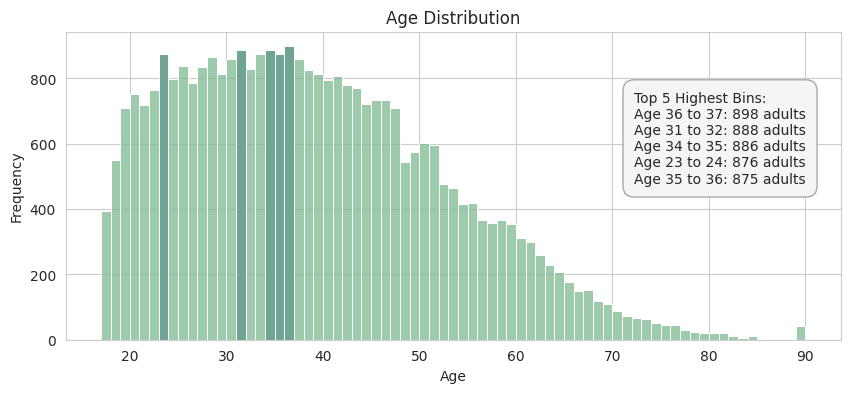

In [ ]:
plt.figure(figsize=(10,4))
age_range = df.age.max() - df.age.min()
ax = sns.histplot(df.age,bins=age_range)

counts, bin_edges, patches = ax.hist(df.age, bins=age_range, alpha=0)
top_indices = np.argsort(counts)[::-1][:5]
top_5 = '\n'.join([f'Age {int(bin_edges[i])} to {int(bin_edges[i+1])}: {int(counts[i])} adults' for i in top_indices])
plt.text(72.25, 480, f'Top 5 Highest Bins:\n{top_5}',bbox=dict(facecolor='whitesmoke', edgecolor='darkgray', boxstyle='round', pad=0.8))
for i in top_indices:
    ax.patches[i].set_facecolor('#70a494')

plt.title('Age Distribution', size='large')
plt.ylabel('Frequency')
plt.xlabel('Age')

plt.show()

In this graph, we see that the data is positively skewed. That is, most of the data is located on the left, which is to be expected of the population group who are in the workforce. We will use this insight later to standardize the age variable, as well as other numerical variables to ensure all features are on a comparable scale. This improves the performance and convergence of machine learning algorithms sensitive to feature magnitude.

## Income by Workclass ⚒️
"Does income level differ significantly across different work classes? If so, which work classes tend to earn more or less?"

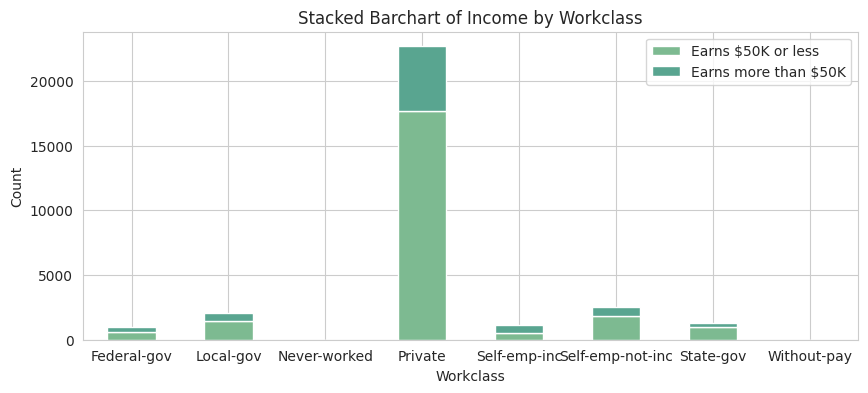

In [ ]:
df_workclass = df.groupby(['workclass','income']).size().reset_index(name='count')
df_workclass = df_workclass.pivot(index='workclass', columns='income', values='count').reset_index()
df_workclass = df_workclass.copy().iloc[1:,:] # Remove the '?' category

df_workclass.set_index('workclass').plot(kind='bar', stacked=True, figsize=(10,4))

plt.xticks(rotation=0)
plt.title('Stacked Barchart of Income by Workclass', size='large')
plt.ylabel('Count')
plt.xlabel('Workclass')
plt.legend(['Earns $50K or less', 'Earns more than $50K'])

plt.show()

In this graph, we see that most of the records in the dataset are under the `Private` workclass. This implies that other workclasses are underrepresented. We will use this insight later on when preprocessing the data for model training.

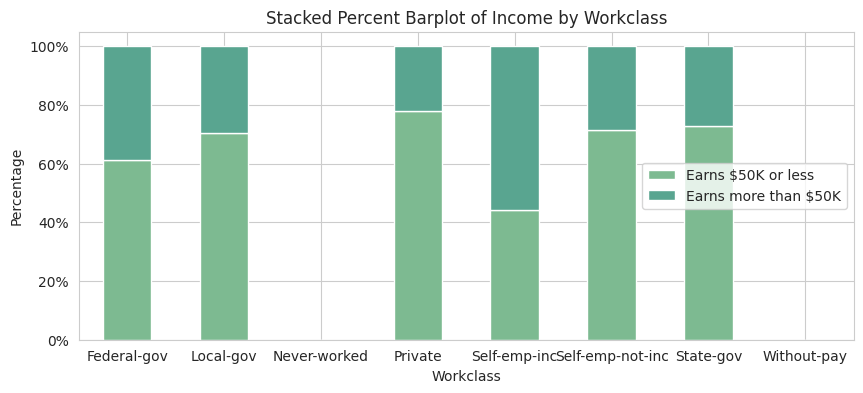

In [ ]:
df_workclass['<=50K_p'] = df_workclass['<=50K'] / (df_workclass['<=50K'] + df_workclass['>50K'])
df_workclass['>50K_p'] = df_workclass['>50K'] / (df_workclass['<=50K'] + df_workclass['>50K'])
df_workclass_percent = df_workclass[['workclass', '<=50K_p', '>50K_p']]

df_workclass_percent.set_index('workclass').plot(kind='bar', stacked=True, figsize=(10,4))

plt.xticks(rotation=0)
plt.title('Stacked Percent Barplot of Income by Workclass', size='large')
plt.ylabel('Percentage')
plt.xlabel('Workclass')
plt.legend(['Earns $50K or less', 'Earns more than $50K'],loc=7)

y_formatter = mtick.FuncFormatter(lambda y, _: f'{int(y*100)}%')
plt.gca().yaxis.set_major_formatter(y_formatter)

plt.show()

We note as well that those under `Private` have the highest percentage of earning \$50K or less, while those under `Self-emp-inc` (Self-employed) have the highest percentage of earning more than \$50K.

It is important to note however that this graph cannot be interpreted on its own, as we have seen in the previous graph that many workclasses are severely underrepresented. Nevertheless, we may be able to use this later in analyzing feature importance.

## Education Level and Income 🎓
"Is there a relationship between the level of education and income? Do individuals with higher levels of education generally earn more?"

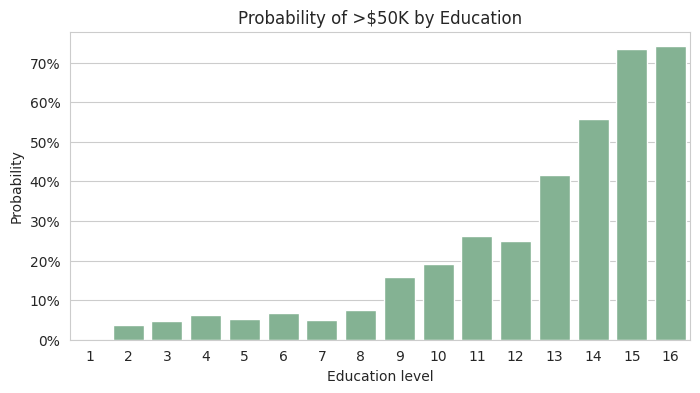

In [ ]:
df_educlevel = df.groupby(['education_num', 'income']).size().reset_index(name='count')
df_educlevel = df_educlevel.pivot(index='education_num', columns='income', values='count').reset_index()
df_educlevel['>50K_p'] = df_educlevel['>50K'] / (df_educlevel['<=50K'] + df_educlevel['>50K'])

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df_educlevel, x='education_num', y='>50K_p')

plt.xticks(rotation=0)
plt.title('Probability of >$50K by Education', size='large')
plt.ylabel('Probability')
plt.xlabel('Education level')

# Format y-axis as percentages
y_formatter = mtick.FuncFormatter(lambda y, _: f'{int(y * 100)}%')
plt.gca().yaxis.set_major_formatter(y_formatter)

plt.show()

In this graph, we note that there is almost an positive exponential relationship between education level and probability of earning more than \$50K. Notably, there is a big jump from education level 12. Once an individual gets past this, the probability increases by roughly 20%. Again, we may be able to use this later in analzying feature importance.

## Hours per Week and Income ⌛
"Is there a correlation between the number of hours worked per week and income? Do people who work more hours generally have a higher income?"

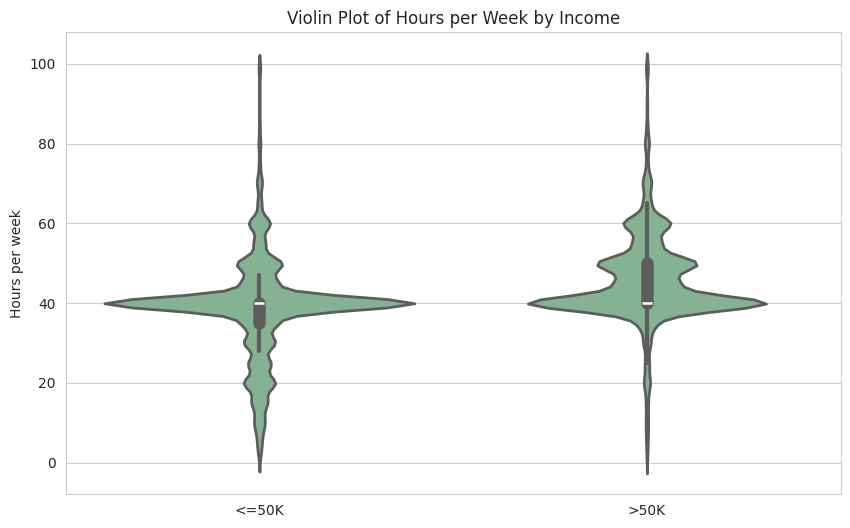

In [ ]:
df_hours = df[['income','hours_per_week']]

plt.figure(figsize=(10,6))
sns.violinplot(data=df_hours, x='income', y='hours_per_week', linewidth=2)

plt.title('Violin Plot of Hours per Week by Income', size='large')
plt.ylabel('Hours per week')
plt.xlabel('')

plt.show()

In this graph, we note that majority of the distribution of `Hours per week` lies around 40 hours. However, it is interesting to note that the violin plot of those who earn more than \$50K is fatter from 40-60 hours compared to those who earn less. This may imply the common intuition that workers who work more (i.e. put in more hours) are more likely to earn more.

This graph helps us two-fold: One is to standardize this distribution as we will do with the `age` feature. Second, we use this insight again in analyzing feature importance.

## Income Distribution by Sex and Race 🧑
"Are there disparities in income levels when broken down by sex and race? Does a specific gender or race tend to earn more?"

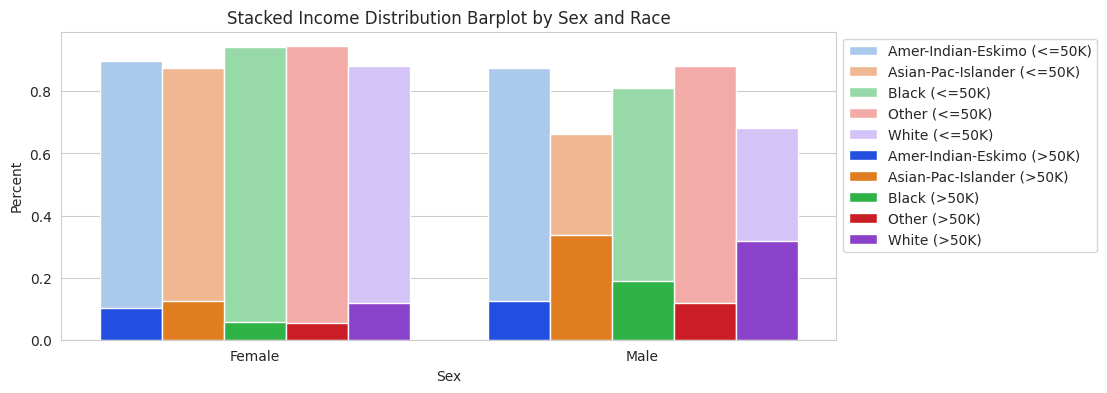

In [ ]:
df_sexrace = df.groupby(['race','sex','income']).size().reset_index(name='count')
df_sexrace = df_sexrace.pivot(index=['sex','race'],columns='income', values='count').reset_index()
df_sexrace['<=50K_p'] = df_sexrace['<=50K'] / (df_sexrace['<=50K'] + df_sexrace['>50K'])
df_sexrace['>50K_p'] = df_sexrace['>50K'] / (df_sexrace['<=50K'] + df_sexrace['>50K'])
df_sexrace['bot'] = df_sexrace['>50K_p'] + df_sexrace['<=50K_p']

plt.figure(figsize=(10,4))
bar1 = sns.barplot(x='sex', y='<=50K_p', hue='race', data=df_sexrace, palette='pastel')
bar2 = sns.barplot(x='sex', y='>50K_p', hue='race', data=df_sexrace, palette='bright')

handles, labels = plt.gca().get_legend_handles_labels()
labels = [f'{i} (<=50K)' if ind<5 else f'{i} (>50K)' for ind,i in enumerate(labels)]
bar1.legend(handles=handles, labels=labels, bbox_to_anchor=(1,1))

plt.title('Stacked Income Distribution Barplot by Sex and Race', size='large')
plt.ylabel('Percent')
plt.xlabel('Sex')

plt.show()

In this graph, we note that males under `Asian-Pac-islander` and `White` are the groups with the largest percentage of earning more than \$50K overall. Looking only at the opposite sex, we seee that these two groupss still dominate although with lesser degree.

Moreover, those classified under `Other`, regardless of gender, appears to have the lowest percentage of >$50K earners.

These results, as with the previous graphs, will be used later with the analysis of feature importance.

### Column Descriptions

In [ ]:
# Ascertain which columns are categorical or quantitative (int64).
for column in df.columns:
    if not pd.api.types.is_numeric_dtype(df[column]):
        df[column] = df[column].astype('category')

# Display columns and descriptions
descriptions = column_descriptions = [
    "Age of the individual", "The employment sector where the individual works", "Final weight by Census Bureau",
    "The highest level of education achieved", "The highest level of education in numerical form", "The marital status of the individual",
    "The individual's general occupation or job role", "The individual's role in their family", "The individual's self-identified race",
    "The individual's self-identified sex", "Capital gains made by the individual", "Capital losses suffered by the individual",
    "The number of hours the individual works per week", "The native country of the individual", "The income level of the individual"]

pd.DataFrame({'Short description':descriptions,'Data type':df.dtypes, 'Null value count':df.isnull().sum()})

,Short description,Data type,Null value count
age,Age of the individual,int64,0
workclass,The employment sector where the individual works,category,0
fnlwgt,Final weight by Census Bureau,int64,0
education,The highest level of education achieved,category,0
education_num,The highest level of education in numerical form,int64,0
marital_status,The marital status of the individual,category,0
occupation,The individual's general occupation or job role,category,0
relationship,The individual's role in their family,category,0
race,The individual's self-identified race,category,0
sex,The individual's self-identified sex,category,0


# Data Preprocessing 🔬

In [ ]:
# Replace categorical columns with "?" values to NAN
for column in columns:
    df[column] = df[column].replace({'?': np.nan})

<ipython-input-110-f5ee189e2804>:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].replace({'?': np.nan})


In [ ]:
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
# Drop NaN values
df.dropna(inplace=True)
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [ ]:
# Assign x and y (input and output variables)
x = df.iloc[:, :-1]
y = df.income

### One-Hot Encoding and Standard Scaling
Before proceeding to model training, we apply One-Hot Encoding and Standard Scaling as preprocessing techniques to prepare the data for model training.
- One-Hot Encoding is done due to our models of choice (Logistic Regression and Random Forest Classifier). These models are more suitable for numerical data. As such, we convert the categorical variables such as education and workclass via this technique.
-  Standard scaling is done due to the results of the Exploratory Data Analysis: Multiple numerical variables, such as `age` and `education_num` are often skewed. Standardizing ensures these features are scaled equally.

In [ ]:
categorical_features = x.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = x.select_dtypes(include=['int64']).columns.tolist()

preprocessor = make_column_transformer(
        (StandardScaler(), numerical_features),
        (OneHotEncoder(), categorical_features),
        remainder='passthrough')

x_processed = preprocessor.fit_transform(x)

# Restore column names
ohe_categories = preprocessor.named_transformers_['onehotencoder'].categories_
ohe_feature_names = [f"{col}_{val}" for col, vals in zip(categorical_features, ohe_categories) for val in vals]
new_feature_names = numerical_features + ohe_feature_names

x_processed = pd.DataFrame(x_processed.toarray(), columns=new_feature_names)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x_processed, y, train_size=0.80, random_state=42)

### Feature Selection
We have decided to conduct Feature selection, (in this case Recursive Feature Elimination with Cross-Validation) as the process of one-hot encoding significantly increased the number of columns.

By identifying and retaining only the most relevant features, RFECV improves model interpretability, reduces overfitting, and decreases computational complexity, while maintaining or enhancing model performance. This ensures the model focuses on the most predictive variables, leading to more efficient and robust results.

In [ ]:
logreg = LogisticRegression(solver='lbfgs', max_iter=400)

selector = RFECV(logreg, step=1, cv=5, scoring='accuracy')
selector = selector.fit(X_train, y_train)

print(selector.ranking_)

[ 1  3  1  1  1  1  1  1 13  1  1  1  1 16  1  1  1  1  9  1  1  6  5 18
  7 19  1  1  8  1  1  1  1  1  1  1  1  1  2  1  1  1  1  1  1  1  1  1
  1 12  1 15  1  1  1  1  1  1  1  1 11  1 10  1  1  1  1  1  1  1  1  1
  1  1  1 14  1 20  1  1  4  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 17  1  1  1]


In [ ]:
# Retain column names
selected_features_mask = selector.support_
selected_columns = X_train.columns[selected_features_mask]

X_train_fix_rfe = pd.DataFrame(selector.transform(X_train), columns=selected_columns)
X_test_fix_rfe = pd.DataFrame(selector.transform(X_test), columns=selected_columns)

In [ ]:
print(f'Previous feature count: {X_test.shape[1]}')
print(f'Current feature count: {X_test_fix_rfe.shape[1]}')

Previous feature count: 104
Current feature count: 85


### Synthetic Minority Oversampling Technique (SMOTE)
We implement oversampling to account for imbalanced features revealed during the Exploratory Data Analysis process. This decision stems from the results of the Exploratory Data Analysis: The distribution of the `workclass` feature reveals that our models may become biased towards the `Private` workclass as it represents a signifiacnt portion of the dataset, underrepresenting other workclasses.

Class imbalance can lead to biased models that favor majority classes, reducing predictive performance for minority classes. SMOTE generates synthetic samples by interpolating between existing minority class datapoints, helping balance the dataset. This enhances the model's ability to learn from both classes effectively, improving its generalization and ensuring fairer predictions across all categories.

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_fix_rfe, y_train)

# Model Creation

Model creation involves iterative hyperparameter tuning using GridSearchCV to optimize model performance. GridSearchCV is applied multiple times, targeting different groups of hyperparameters to systematically explore their combinations. Initially, a broad search is conducted with values like 1, 10, 100, and 1000 for key parameters, providing a general sense of the model's sensitivity.

Based on these results, the search is refined to smaller, more precise ranges around promising values, ensuring a more focused and efficient optimization process.

## Logistic Regression 📈

In [ ]:
param_grid = {
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
}

# Run grid search
grid_search = GridSearchCV(LogisticRegression(C=1, penalty='l2'), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=3) # l2 is the common penalty for all solvers
grid_search.fit(X_train_smote, y_train_smote)

# Extract the best estimator
print(grid_search.best_score_)
print(grid_search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
0.9079066992180996
{'solver': 'sag'}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# Find best parameters
param_grid = {
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'penalty': ['l2', None] # l1 is not applicable with the `sag` solver
}

# Run grid search
grid_search = GridSearchCV(LogisticRegression(solver='sag'), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=3)
grid_search.fit(X_train_smote, y_train_smote)

# Extract the best estimator
print(grid_search.best_score_)
print(grid_search.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
0.9079068965414627
{'C': 1, 'penalty': 'l2'}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# Find best parameters
param_grid = {
    'C': np.arange(0.8,1.2,0.05),
}

# Run grid search
grid_search = GridSearchCV(LogisticRegression(solver='sag', penalty='l2'), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=3)
grid_search.fit(X_train_smote, y_train_smote)

# Extract the best estimator
print(grid_search.best_score_)
print(grid_search.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
0.9079072606229133
{'C': 0.9500000000000002}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
model_logreg = LogisticRegression(
    solver='sag',
    C=0.9,
    max_iter=4000,
    penalty='l2')

model_logreg.fit(X_train_smote, y_train_smote)

LogisticRegression(C=0.9, max_iter=4000, solver='sag')

## Random Forest Classifier 🌲

In [ ]:
# Find best n_estimator
param_grid = {
    'n_estimators': [100,200,500],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=3)
grid_search.fit(X_train_smote, y_train_smote)

print(grid_search.best_score_)
print(grid_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
0.9177487209788318
{'criterion': 'entropy', 'max_depth': 8, 'n_estimators': 200}


In [ ]:
# Find best n_estimator
param_grid = {
    'n_estimators': np.arange(150,250,25),
    'max_depth' : np.arange(12,20,30),
}

grid_search = GridSearchCV(RandomForestClassifier(criterion='gini'), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=3)
grid_search.fit(X_train_smote, y_train_smote)

print(grid_search.best_score_)
print(grid_search.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
0.9317947651302511
{'max_depth': 12, 'n_estimators': 200}


In [ ]:
# Find best n_estimator
param_grid = {
    'n_estimators': np.arange(200,250,1)
}

grid_search = GridSearchCV(RandomForestClassifier(criterion='gini', max_depth=12), param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=3)
grid_search.fit(X_train_smote, y_train_smote)

print(grid_search.best_score_)
print(grid_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.9316442715398423
{'n_estimators': 231}


In [ ]:
model_rfc = RandomForestClassifier(
    n_estimators=223,
    criterion='gini',
    max_depth=12
)

model_rfc.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=12, n_estimators=223)

In [ ]:
import pickle

progress = {
    'logreg' : model_logreg,
    'rfc' : model_rfc,
    'x_train' : X_train_smote,
    'y_train' : y_train_smote,
    'x_test' : X_test_fix_rfe,
    'y_test' : y_test
}

with open('progress.pkl', 'wb') as f:
    pickle.dump(progress, f)

# Model Evaluation
For model evaluation, we compare the two binary classification models using a combination of metrics and visual tools to assess their performance. First, we analyze the confusion matrix to evaluate the distribution of true positives, true negatives, false positives, and false negatives, providing insight into prediction accuracy and errors. We also generate a classification report to review precision, recall, and F1-score for each class.

The primary evaluation metric is the AUC (Area Under the Curve) score, as it measures the ability of the model to distinguish between classes across all classification thresholds, making it robust to class imbalance. A higher AUC indicates better model discrimination, which is particularly important in our scenario. We then plot the ROC (Receiver Operating Characteristic) curve for each model to visualize the trade-off between the true positive rate (sensitivity) and false positive rate for better comparison.

Finally, we look at the rankings of what features each model deemed important. This also ties with insights from the Exploratory Data Analysis.

In [ ]:
# Make predictions
y_pred_logreg = model_logreg.predict(X_test_fix_rfe)
y_pred_rf = model_rfc.predict(X_test_fix_rfe)

In [ ]:
# Confusion Matrices
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix:
[[3611  874]
 [ 234 1309]]
Random Forest Confusion Matrix:
[[3537  948]
 [ 185 1358]]


In [ ]:
# Model Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.81      0.87      4485
        >50K       0.60      0.85      0.70      1543

    accuracy                           0.82      6028
   macro avg       0.77      0.83      0.78      6028
weighted avg       0.85      0.82      0.82      6028

Random Forest Classification Report:
              precision    recall  f1-score   support

       <=50K       0.95      0.79      0.86      4485
        >50K       0.59      0.88      0.71      1543

    accuracy                           0.81      6028
   macro avg       0.77      0.83      0.78      6028
weighted avg       0.86      0.81      0.82      6028



Class-Specific Performance:

For the `<=50K` class, Random Forest has slightly better precision (0.95 vs. 0.94) but lower recall (0.79 vs. 0.81) compared to Logistic Regression, resulting in similar F1-scores (0.86 vs. 0.87).

For the `>50K class`, Logistic Regression has slightly higher recall (0.85 vs. 0.88 for Random Forest), but both models achieve the same F1-score (0.70).

- Overall Accuracy: Logistic Regression achieves higher accuracy (0.83 vs. 0.81), indicating slightly better overall prediction performance.

- Averaged Metrics: The macro-average recall is identical for both models (0.83), but Logistic Regression has a higher macro-average F1-score (0.79 vs. 0.78). The weighted average F1-score is higher for Logistic Regression (0.83 vs. 0.82), suggesting it may generalize slightly better.

While both models perform similarly, Logistic Regression shows a slight edge in overall accuracy and weighted F1-score, indicating better balance across both classes. Random Forest provides marginally higher precision for the majority class (<=50K) but sacrifices some recall.

In [ ]:
# AUC Scores
logreg_auc = roc_auc_score(y_test, model_logreg.predict_proba(X_test_fix_rfe)[:, 1])
rf_auc = roc_auc_score(y_test, model_rfc.predict_proba(X_test_fix_rfe)[:, 1])
print(f"Logistic Regression AUC: {logreg_auc}")
print(f"Random Forest AUC: {rf_auc}")

Logistic Regression AUC: 0.909895735117635
Random Forest AUC: 0.9161273518482795


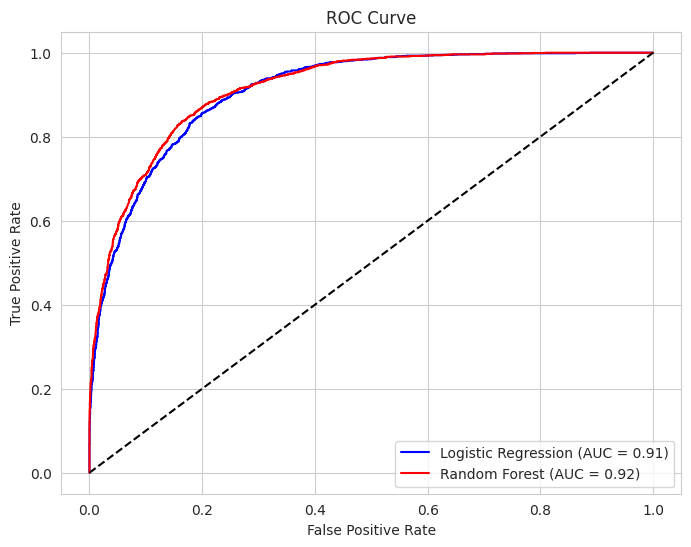

In [ ]:
# Plot ROC Curves
import matplotlib.pyplot as plt
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, model_logreg.predict_proba(X_test_fix_rfe)[:, 1], pos_label='>50K')
fpr_rf, tpr_rf, _ = roc_curve(y_test, model_rfc.predict_proba(X_test_fix_rfe)[:, 1], pos_label='>50K')

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {logreg_auc:.2f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})', color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.savefig('ROC Curve.eps', format='eps', dpi=300)
plt.legend()
plt.show()

The ROC curve compares the performance of Logistic Regression (blue) and Random Forest (red) models. Both curves are well above the diagonal (random chance line), indicating strong classification performance. The Random Forest model shows a slightly higher true positive rate (TPR) for the same false positive rate (FPR), suggesting better discrimination.

The AUC for Logistic Regression is 0.91, while Random Forest achieves a slightly higher AUC of 0.92. With AUC values close to 1.0, both models demonstrate excellent performance, though Random Forest has a marginal advantage.

In [ ]:
import pickle

In [ ]:
# Recover trained models
with open('progress.pkl', 'rb') as file:
    progress = pickle.load(file)

In [ ]:
logreg = progress['logreg']
rfc = progress['rfc']
feature_names = progress['x_train'].columns.tolist()

## Feature Importance for Logistic Regression

In [ ]:
def rank_features_logistic_regression(model, feature_names=feature_names):
    """
    Rank features based on their coefficients in a Logistic Regression model.
    """

    # Get coefficients
    feature_importance = model.coef_[0]

    # Create DataFrame
    ranking_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': feature_importance,
        'Abs_Coefficient': np.abs(feature_importance) # Take magnitude (absolute value)
    })

    # Sort by absolute coefficient value
    ranking_df = ranking_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)
    ranking_df['Rank'] = ranking_df.index + 1  # Add rank column

    return ranking_df

def rank_features_random_forest(rfc_model, feature_names=feature_names):
    """
    Rank features based on their importance in a Random Forest Classifier.
    """

    # Get feature importances
    feature_importances = rfc_model.feature_importances_

    # Create DataFrame for ranking
    ranking_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # Sort by importance
    ranking_df = ranking_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    ranking_df['Rank'] = ranking_df.index + 1  # Add rank column

    return ranking_df


In [ ]:
ranking_logreg = rank_features_logistic_regression(logreg, feature_names)
ranking_rfc = rank_features_random_forest(rfc, feature_names)

In [ ]:
ranking_logreg.head(10) # A negative coefficient implies the feature affects datapoints negatively (i.e. to be classified with label 0 or <50K)

,Feature,Coefficient,Abs_Coefficient,Rank
0,capital_gain,2.373157,2.373157,1
1,occupation_Priv-house-serv,-2.253580,2.253580,2
2,native_country_Columbia,-1.621874,1.621874,3
3,workclass_Without-pay,-1.568605,1.568605,4
4,marital_status_Married-civ-spouse,1.568251,1.568251,5
5,native_country_Cambodia,1.395571,1.395571,6
6,relationship_Own-child,-1.306606,1.306606,7
7,occupation_Farming-fishing,-1.250233,1.250233,8
8,marital_status_Married-AF-spouse,1.243535,1.243535,9
9,relationship_Wife,1.200620,1.200620,10


We note the following observations:
1. `capital_gain` is the largest positive coefficient for the model. This implies that the model sees this feature contributing the most to an individual's capacity to earn more than \$50K. This is an intuitive result as `capital_gain` represents profits gained from the sale of capital assets.
2. `occupation_Priv-house-serv` is the largest negative coefficient for the model. This feature is indicating an individual who works as a private house servant. This too can be thought as an intuitive result as this line of work is often associated with low pay.

Connecting with the Exploratory Data Analysis, we also note the following:

3. We have previously noted that the those classified as `Other` in race tends to have the lowest percentage of >$50K earners. This result appears to correlate with the ranked #3 feature, `native_country_Colombia`, The model sees this feature as negatively contributing to earners earning more than \$50K. It is interesting though to note that `native_country_Camobdia` has a positive coefficient.
4. `occupation-Farming-fishing` is also viewed negatively by the model. This may reflect the poor economic situation in this sector.
5. Notably, features we have explored in the EDA, including `hours_per_week` and `education_level` were not present.

In [ ]:
ranking_rfc.head(10)

,Feature,Importance,Rank
0,marital_status_Married-civ-spouse,0.199585,1
1,education_num,0.118666,2
2,age,0.092899,3
3,relationship_Husband,0.089857,4
4,capital_gain,0.081646,5
5,marital_status_Never-married,0.071917,6
6,hours_per_week,0.061167,7
7,relationship_Own-child,0.029162,8
8,occupation_Exec-managerial,0.027035,9
9,sex_Female,0.026955,10


We note the following observations:
1. `marital_status_Married-civ-spouse` is interpreted as the most important feature. This feature implies that an indivual is married corresponds to a civilian spouse. This may reflect the majority of the working class. `marital_status_Never-married`, `relationship_Husband`, and `relationship_Own-child` are also deemed important. This implies that the model tends to connect an individual's marital and familial responsibilities as an important factor for earning more money.
2. `capital_gain` is also on the list but not as significant in the previous model.
3. Finally, we see that an Executive-managerial occupation also made it to the list. This is likely a positive contribution as this line of work is often associated with high salaries.

Connecting with the Exploratory Data Analysis, we also note the following:

4. We also note that `education_num` is ranked #2. This may affirm the observation in the EDA about the upward trend of `education_num`. Notably, this feature was not regarded as significant for the Logistic Regression model.
5. This observation is also similar for `hours_per_week`.

# Model Evaluation Conclusion
Depending on the use case, if recall for the minority class (>50K) is critical, Logistic Regression may be the better choice. However, if we base on the AUC scores, Random Forest slightly outperforms Logistic Regression in distinguishing between classes.

We note that Random Forest may outperform Logistic Regression in AUC score slightly as it is better at determining non-linear patterns within the data. Logistic Regression is limited in so far as linear associations. Patterns such as marital and familial duties (which Random Forest emphasized) may be a non-linear one. Moreover, the capital gain variable can be thought of as a "linear" or a directly-affecting factor to income, which Logistic Regression regards as most important.

We also note that more techniques may be introduced to handle class imbalanced, as we see that the Logistic Regression model is biased to certain races as noted in feature importance.